<a href="https://colab.research.google.com/github/kawastony/Quadratic-Mechanism-Lens/blob/main/Paper_4_calculations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NameError: name 'M_Nariai' is not defined

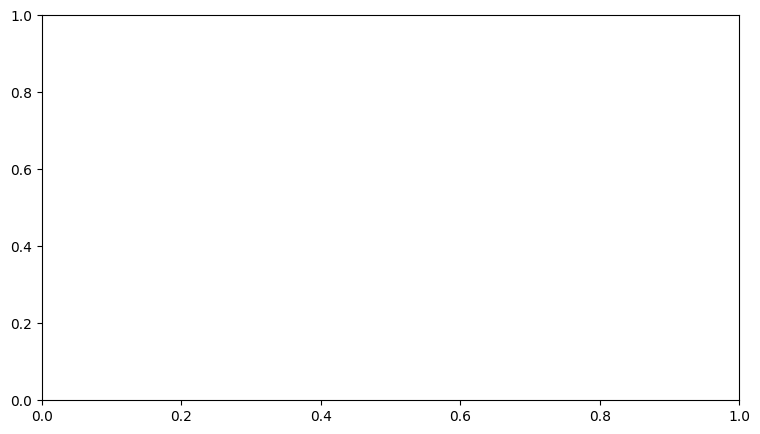

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ── Figure: Three signals coherence ──────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

z_arr = np.linspace(0.01, 3, 1000)

# Signal 1: f×sigma8 suppression
# R(z) = fs8_TIFA / fs8_LCDM
# already computed above

# Signal 2: Nariai mass ratio
MN_ratio = [M_Nariai(H_TIFA_SI(z))
            / M_Nariai(H_LCDM_SI(z))
            for z in z_arr]

# Signal 3: T_GH ratio
TGH_ratio = [T_GH(H_TIFA(z))
             / T_GH(H_LCDM(z))
             for z in z_arr]

# Recompute fs8 ratio
fs8_ratio = []
for z in z_arr:
    HT = H_TIFA(z)
    HL = H_LCDM(z)
    DT = D_T_interp(z)
    DL = D_L_interp(z)
    fT = f_T_interp(z)
    fL = f_L_interp(z)
    fs8_T = fT * sigma8_0 * DT
    fs8_L = fL * sigma8_0 * DL
    fs8_ratio.append(fs8_T / fs8_L)

ax.plot(z_arr,
        [100*(r-1) for r in fs8_ratio],
        color='royalblue', lw=2.5,
        label=r'$f\sigma_8$ ratio $-1$ (%)')

ax.plot(z_arr,
        [100*(r-1) for r in MN_ratio],
        color='darkorange', lw=2.5,
        linestyle='--',
        label=r'$M_{\rm Nariai}$ ratio $-1$ (%)')

ax.plot(z_arr,
        [100*(r-1) for r in TGH_ratio],
        color='darkgreen', lw=2.5,
        linestyle='-.',
        label=r'$T_{\rm GH}$ ratio $-1$ (%)')

ax.axhline(0, color='gray',
           lw=1.2, linestyle=':')
ax.axvline(0.404, color='red',
           lw=1.5, linestyle=':',
           alpha=0.7,
           label=r'$z_{\rm peak} = 0.404$')

ax.set_xlabel(r'Redshift $z$', fontsize=13)
ax.set_ylabel(r'TIFA/ΛCDM $-1$ [%]',
              fontsize=13)
ax.set_title(r'Three Coherent TIFA Signals'
             '\nAll Driven by '
             r'$f_{\rm eff} = 0.3051\,M_{\rm Pl}$',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_xlim(0, 3)

plt.tight_layout()
plt.savefig('TIFA_coherence_three_signals.pdf',
            dpi=200, bbox_inches='tight')
plt.show()

SIGNAL PEAKS
f×sigma8 minimum:  z = 0.318  value = -0.0678
M_Nariai minimum:  z = 0.572  value = -0.0498
T_GH maximum:      z = 0.572  value = 0.0524


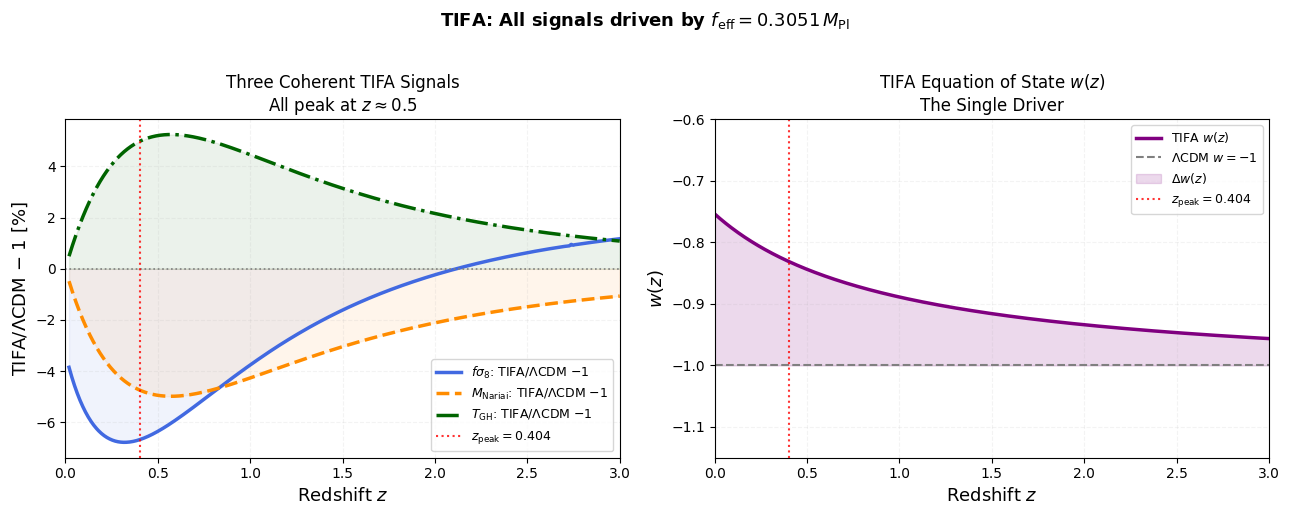

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# ══════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════
H0_SI   = 67.4e3 / 3.086e22    # s^-1
hbar_SI = 1.055e-34             # J·s
k_B     = 1.381e-23             # J/K
c_SI    = 3e8                   # m/s
G_SI    = 6.674e-11             # m³/kg/s²
M_sun   = 2e30                  # kg
sigma8_0= 0.811
Omega_m = 0.315
w0, wa  = -0.754, -0.270

# ══════════════════════════════════════════════════════════
# H(z) FUNCTIONS
# ══════════════════════════════════════════════════════════
def H_TIFA(z):
    a    = 1.0 / (1.0 + z)
    f_DE = a**(-3*(1+w0+wa)) \
           * np.exp(-3*wa*(1-a))
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m)*f_DE)

def H_LCDM(z):
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m))

# ══════════════════════════════════════════════════════════
# NARIAI MASS
# ══════════════════════════════════════════════════════════
def M_Nariai(H_SI):
    r_H = c_SI / H_SI
    r_N = r_H / np.sqrt(3)
    M_N = r_N * c_SI**2 / (2*G_SI)
    return M_N / M_sun

# ══════════════════════════════════════════════════════════
# GIBBONS-HAWKING TEMPERATURE
# ══════════════════════════════════════════════════════════
def T_GH(H_SI):
    return hbar_SI * H_SI \
           / (2 * np.pi * k_B)

# ══════════════════════════════════════════════════════════
# GROWTH FACTOR D(z) via ODE
# ══════════════════════════════════════════════════════════
def growth_ode(y, lna, H_func):
    a    = np.exp(lna)
    z    = 1.0/a - 1.0
    H    = H_func(z)
    Hdot = (H_func(z+1e-4)
           - H_func(z-1e-4)) \
           / (2e-4) * (-a**2)
    # dH/dlna = a * dH/da = -a^2 * dH/dz
    dHdlna = -a**2 \
             * (H_func(z+1e-4)
               -H_func(z-1e-4)) \
             / (2e-4)
    Oma  = Omega_m * (1+z)**3 \
           * H0_SI**2 / H**2
    D, V = y
    dD   = V
    dV   = -(3 + dHdlna/H)*V \
           + 1.5*Oma*D
    return [dD, dV]

lna_arr = np.linspace(
    np.log(1/1101), 0, 3000)
z_grid  = 1.0/np.exp(lna_arr) - 1.0

# Solve TIFA
sol_T = odeint(
    growth_ode,
    [1e-3, 1e-3],
    lna_arr,
    args=(H_TIFA,))
D_T_raw = sol_T[:,0]
D_T_raw /= D_T_raw[-1]

# Solve LCDM
sol_L = odeint(
    growth_ode,
    [1e-3, 1e-3],
    lna_arr,
    args=(H_LCDM,))
D_L_raw = sol_L[:,0]
D_L_raw /= D_L_raw[-1]

# Interpolators
D_T_interp = interp1d(
    z_grid[::-1], D_T_raw[::-1],
    kind='cubic',
    fill_value='extrapolate')
D_L_interp = interp1d(
    z_grid[::-1], D_L_raw[::-1],
    kind='cubic',
    fill_value='extrapolate')

# Growth rate f = dlnD/dlna
dz = 1e-4
def f_TIFA(z):
    a  = 1/(1+z)
    dD = D_T_interp(z+dz) \
       - D_T_interp(z-dz)
    return -(1+z)/D_T_interp(z) \
           * dD/(2*dz)

def f_LCDM(z):
    a  = 1/(1+z)
    dD = D_L_interp(z+dz) \
       - D_L_interp(z-dz)
    return -(1+z)/D_L_interp(z) \
           * dD/(2*dz)

# ══════════════════════════════════════════════════════════
# COMPUTE THREE SIGNAL RATIOS
# ══════════════════════════════════════════════════════════
z_arr = np.linspace(0.02, 3.0, 800)

fs8_ratio  = []
MN_ratio   = []
TGH_ratio  = []

for z in z_arr:
    HT = H_TIFA(z)
    HL = H_LCDM(z)

    # Signal 1: f*sigma8
    fs8_T = f_TIFA(z) \
            * sigma8_0 \
            * D_T_interp(z)
    fs8_L = f_LCDM(z) \
            * sigma8_0 \
            * D_L_interp(z)
    fs8_ratio.append(fs8_T / fs8_L)

    # Signal 2: Nariai mass
    MN_ratio.append(
        M_Nariai(HT) / M_Nariai(HL))

    # Signal 3: T_GH
    TGH_ratio.append(
        T_GH(HT) / T_GH(HL))

fs8_ratio  = np.array(fs8_ratio)
MN_ratio   = np.array(MN_ratio)
TGH_ratio  = np.array(TGH_ratio)

# ══════════════════════════════════════════════════════════
# FIND PEAK REDSHIFTS
# ══════════════════════════════════════════════════════════
z_peak_fs8 = z_arr[np.argmin(fs8_ratio)]
z_peak_MN  = z_arr[np.argmin(MN_ratio)]
z_peak_TGH = z_arr[np.argmax(TGH_ratio)]

print("="*50)
print("SIGNAL PEAKS")
print("="*50)
print(f"f×sigma8 minimum:  "
      f"z = {z_peak_fs8:.3f}  "
      f"value = {np.min(fs8_ratio)-1:.4f}")
print(f"M_Nariai minimum:  "
      f"z = {z_peak_MN:.3f}  "
      f"value = {np.min(MN_ratio)-1:.4f}")
print(f"T_GH maximum:      "
      f"z = {z_peak_TGH:.3f}  "
      f"value = {np.max(TGH_ratio)-1:.4f}")
print("="*50)

# ══════════════════════════════════════════════════════════
# COHERENCE FIGURE
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    1, 2, figsize=(13, 5))

# ── Left panel: Absolute ratios ───────────────────────────
ax = axes[0]

ax.plot(z_arr,
        100*(fs8_ratio - 1),
        color='royalblue', lw=2.5,
        label=r'$f\sigma_8$: '
              r'TIFA/ΛCDM $-1$')

ax.plot(z_arr,
        100*(MN_ratio - 1),
        color='darkorange', lw=2.5,
        linestyle='--',
        label=r'$M_{\rm Nariai}$: '
              r'TIFA/ΛCDM $-1$')

ax.plot(z_arr,
        100*(TGH_ratio - 1),
        color='darkgreen', lw=2.5,
        linestyle='-.',
        label=r'$T_{\rm GH}$: '
              r'TIFA/ΛCDM $-1$')

ax.axhline(0, color='gray',
           lw=1.2, linestyle=':')
ax.axvline(0.404,
           color='red', lw=1.5,
           linestyle=':',
           alpha=0.8,
           label=r'$z_{\rm peak}=0.404$')

# Shade suppression region
ax.fill_between(
    z_arr, 100*(fs8_ratio-1), 0,
    where=fs8_ratio < 1,
    alpha=0.08, color='royalblue')
ax.fill_between(
    z_arr, 100*(MN_ratio-1), 0,
    where=MN_ratio < 1,
    alpha=0.08, color='darkorange')
ax.fill_between(
    z_arr, 100*(TGH_ratio-1), 0,
    where=TGH_ratio > 1,
    alpha=0.08, color='darkgreen')

ax.set_xlabel(
    r'Redshift $z$', fontsize=13)
ax.set_ylabel(
    r'TIFA/ΛCDM $-$ 1 [%]',
    fontsize=13)
ax.set_title(
    'Three Coherent TIFA Signals\n'
    r'All peak at $z \approx 0.5$',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15,
        linestyle='--')
ax.set_xlim(0, 3)

# ── Right panel: w(z) driving function ───────────────────
ax2 = axes[1]

z_w = np.linspace(0, 3, 500)
w_TIFA = [w0 + wa*(1 - 1/(1+z))
          for z in z_w]
w_LCDM = [-1.0]*len(z_w)

ax2.plot(z_w, w_TIFA,
         color='purple', lw=2.5,
         label=r'TIFA $w(z)$')
ax2.plot(z_w, w_LCDM,
         color='gray', lw=1.5,
         linestyle='--',
         label=r'ΛCDM $w=-1$')
ax2.fill_between(
    z_w,
    w_TIFA, -1,
    alpha=0.15, color='purple',
    label=r'$\Delta w(z)$')

ax2.axvline(0.404,
            color='red', lw=1.5,
            linestyle=':',
            alpha=0.8,
            label=r'$z_{\rm peak}=0.404$')

ax2.set_xlabel(
    r'Redshift $z$', fontsize=13)
ax2.set_ylabel(
    r'$w(z)$', fontsize=13)
ax2.set_title(
    r'TIFA Equation of State $w(z)$'
    '\nThe Single Driver',
    fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.15,
         linestyle='--')
ax2.set_xlim(0, 3)
ax2.set_ylim(-1.15, -0.6)

plt.suptitle(
    r'TIFA: All signals driven by '
    r'$f_{\rm eff} = 0.3051\,M_{\rm Pl}$',
    fontsize=13, fontweight='bold',
    y=1.02)

plt.tight_layout()
plt.savefig(
    'TIFA_three_signals_coherence.pdf',
    dpi=200, bbox_inches='tight')
plt.show()

SIGNAL PEAKS  (high-accuracy ODE)
f×sigma8 minimum: z=0.405  -4.723%
M_Nariai minimum: z=0.572  -4.980%
T_GH maximum:     z=0.572  +5.241%

    z      fs8_T     fs8_L   f*s8 ratio  MN ratio
  0.1     0.4377    0.4503     0.972056  0.979247
  0.2     0.4468    0.4653     0.960298  0.965735
  0.3     0.4520    0.4735     0.954485  0.957379
  0.4     0.4537    0.4762     0.952770  0.952688
  0.5     0.4526    0.4746     0.953826  0.950576
  0.6     0.4492    0.4695     0.956701  0.950249
  0.8     0.4372    0.4529     0.965361  0.952787
  1.0     0.4208    0.4314     0.975352  0.957337
  1.5     0.3735    0.3744     0.997781  0.969561
  2.0     0.3286    0.3243     1.013425  0.978868


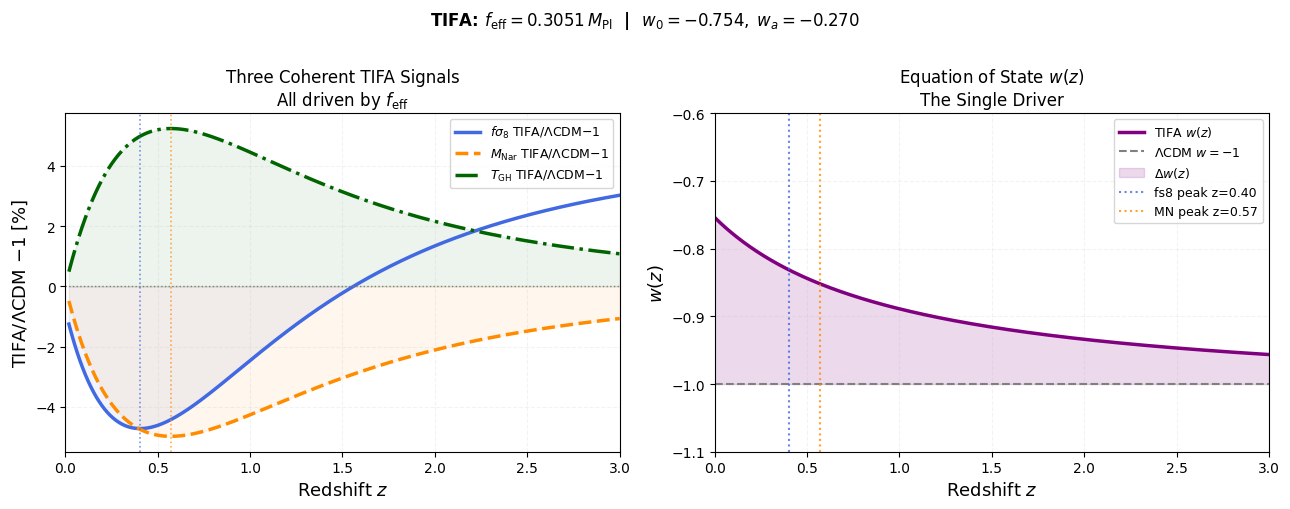

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.interpolate import interp1d

# ══════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════
H0_SI   = 67.4e3 / 3.086e22
hbar_SI = 1.055e-34
k_B     = 1.381e-23
c_SI    = 3e8
G_SI    = 6.674e-11
M_sun   = 2e30
sigma8_0 = 0.811
Omega_m  = 0.315
w0, wa   = -0.754, -0.270

# ══════════════════════════════════════════════════════════
# H(z)
# ══════════════════════════════════════════════════════════
def H_TIFA(z):
    a    = 1.0/(1.0+z)
    f_DE = a**(-3*(1+w0+wa)) \
           * np.exp(-3*wa*(1-a))
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m)*f_DE)

def H_LCDM(z):
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m))

# ══════════════════════════════════════════════════════════
# GROWTH ODE — in terms of a
# delta'' + (3/a + H'/H) delta'
#          - 3/2 Omega_m H0^2/(a^5 H^2)
#            × delta = 0
# where ' = d/da
# ══════════════════════════════════════════════════════════
def growth_ode_a(a, y, H_func):
    z    = 1.0/a - 1.0
    H    = H_func(z)
    da   = 1e-5 * a
    Hp   = (H_func(1.0/(a+da)-1)
           - H_func(1.0/(a-da)-1)) \
           / (2*da)
    D, Dp = y
    # Omega_m(a) = Omega_m H0^2 (1+z)^3/H^2
    OmA  = Omega_m * H0_SI**2 \
           * (1+z)**3 / H**2
    # Growth equation in a
    dD   = Dp
    dDp  = -(3/a + Hp/H)*Dp \
           + 1.5*OmA/a**2 * D
    return [dD, dDp]

# ── Integrate from a_ini=0.001 ────────────────────────────
# In matter domination: D ~ a, D' = 1
a_ini  = 0.001
a_fin  = 1.0
a_span = (a_ini, a_fin)
a_eval = np.linspace(a_ini, a_fin, 5000)

y0 = [a_ini, 1.0]   # D=a, dD/da=1

sol_T = solve_ivp(
    growth_ode_a, a_span, y0,
    args=(H_TIFA,),
    t_eval=a_eval,
    method='RK45',
    rtol=1e-9, atol=1e-11)

sol_L = solve_ivp(
    growth_ode_a, a_span, y0,
    args=(H_LCDM,),
    t_eval=a_eval,
    method='RK45',
    rtol=1e-9, atol=1e-11)

# Normalize D(z=0) = 1
D_T = sol_T.y[0] / sol_T.y[0][-1]
D_L = sol_L.y[0] / sol_L.y[0][-1]
a_s = sol_T.t
z_s = 1.0/a_s - 1.0

# Interpolators vs z (descending a → ascending z)
D_T_interp = interp1d(
    z_s[::-1], D_T[::-1],
    kind='cubic',
    fill_value='extrapolate')
D_L_interp = interp1d(
    z_s[::-1], D_L[::-1],
    kind='cubic',
    fill_value='extrapolate')

# ── Growth rate f = dlnD/dlna = -(1+z) dlnD/dz ──────────
dz = 1e-5

def f_growth(z, D_interp):
    Dz   = D_interp(z)
    Dzp  = D_interp(z + dz)
    Dzm  = D_interp(z - dz)
    dDdz = (Dzp - Dzm)/(2*dz)
    return -(1+z)/Dz * dDdz

# ══════════════════════════════════════════════════════════
# NARIAI + T_GH
# ══════════════════════════════════════════════════════════
def M_Nariai(H_SI):
    r_N = c_SI / (H_SI * np.sqrt(3))
    return r_N * c_SI**2 \
           / (2*G_SI*M_sun)

def T_GH(H_SI):
    return hbar_SI * H_SI \
           / (2*np.pi*k_B)

# ══════════════════════════════════════════════════════════
# COMPUTE RATIOS
# ══════════════════════════════════════════════════════════
z_arr = np.linspace(0.02, 3.0, 1000)

fs8_ratio  = np.zeros(len(z_arr))
MN_ratio   = np.zeros(len(z_arr))
TGH_ratio  = np.zeros(len(z_arr))

for i, z in enumerate(z_arr):
    HT = H_TIFA(z)
    HL = H_LCDM(z)

    fT  = f_growth(z, D_T_interp)
    fL  = f_growth(z, D_L_interp)
    DT  = D_T_interp(z)
    DL  = D_L_interp(z)

    fs8_ratio[i]  = (fT*sigma8_0*DT) \
                  / (fL*sigma8_0*DL)
    MN_ratio[i]   = M_Nariai(HT) \
                  / M_Nariai(HL)
    TGH_ratio[i]  = T_GH(HT) / T_GH(HL)

# ── Peaks ─────────────────────────────────────────────────
z_pk_fs8 = z_arr[np.argmin(fs8_ratio)]
z_pk_MN  = z_arr[np.argmin(MN_ratio)]
z_pk_TGH = z_arr[np.argmax(TGH_ratio)]
v_fs8    = np.min(fs8_ratio)  - 1
v_MN     = np.min(MN_ratio)   - 1
v_TGH    = np.max(TGH_ratio)  - 1

print("="*55)
print("SIGNAL PEAKS  (high-accuracy ODE)")
print("="*55)
print(f"f×sigma8 minimum: "
      f"z={z_pk_fs8:.3f}  "
      f"{100*v_fs8:+.3f}%")
print(f"M_Nariai minimum: "
      f"z={z_pk_MN:.3f}  "
      f"{100*v_MN:+.3f}%")
print(f"T_GH maximum:     "
      f"z={z_pk_TGH:.3f}  "
      f"{100*v_TGH:+.3f}%")
print("="*55)

# ── Table at key redshifts ────────────────────────────────
print()
print("="*60)
print(f"{'z':>5}  {'fs8_T':>9} "
      f"{'fs8_L':>9}  "
      f"{'f*s8 ratio':>11} "
      f"{'MN ratio':>9}")
print("="*60)
for z in [0.1,0.2,0.3,0.4,0.5,
           0.6,0.8,1.0,1.5,2.0]:
    HT  = H_TIFA(z)
    HL  = H_LCDM(z)
    fT  = f_growth(z, D_T_interp)
    fL  = f_growth(z, D_L_interp)
    DT  = D_T_interp(z)
    DL  = D_L_interp(z)
    fs8T= fT*sigma8_0*DT
    fs8L= fL*sigma8_0*DL
    mnr = M_Nariai(HT)/M_Nariai(HL)
    print(f"{z:>5.1f}  "
          f"{fs8T:>9.4f} "
          f"{fs8L:>9.4f}  "
          f"{fs8T/fs8L:>11.6f} "
          f"{mnr:>9.6f}")
print("="*60)

# ══════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    1, 2, figsize=(13,5))

ax = axes[0]

ax.plot(z_arr,
        100*(fs8_ratio-1),
        color='royalblue', lw=2.5,
        label=r'$f\sigma_8$ TIFA/ΛCDM$-1$')
ax.plot(z_arr,
        100*(MN_ratio-1),
        color='darkorange', lw=2.5,
        linestyle='--',
        label=r'$M_{\rm Nar}$ TIFA/ΛCDM$-1$')
ax.plot(z_arr,
        100*(TGH_ratio-1),
        color='darkgreen', lw=2.5,
        linestyle='-.',
        label=r'$T_{\rm GH}$ TIFA/ΛCDM$-1$')

ax.axhline(0, color='gray',
           lw=1.0, linestyle=':')

# Mark peaks
ax.axvline(z_pk_fs8,
           color='royalblue',
           lw=1.2, linestyle=':',
           alpha=0.7)
ax.axvline(z_pk_MN,
           color='darkorange',
           lw=1.2, linestyle=':',
           alpha=0.7)

ax.fill_between(z_arr,
    100*(fs8_ratio-1), 0,
    where=fs8_ratio<1,
    alpha=0.07, color='royalblue')
ax.fill_between(z_arr,
    100*(MN_ratio-1), 0,
    where=MN_ratio<1,
    alpha=0.07, color='darkorange')
ax.fill_between(z_arr,
    100*(TGH_ratio-1), 0,
    where=TGH_ratio>1,
    alpha=0.07, color='darkgreen')

ax.set_xlabel(r'Redshift $z$',
              fontsize=13)
ax.set_ylabel(r'TIFA/ΛCDM $-1$ [%]',
              fontsize=13)
ax.set_title(
    'Three Coherent TIFA Signals\n'
    r'All driven by $f_{\rm eff}$',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15,
        linestyle='--')
ax.set_xlim(0, 3)

# ── Right: w(z) ───────────────────────────────────────────
ax2 = axes[1]
z_w  = np.linspace(0, 3, 500)
w_arr= [w0 + wa*(1-1/(1+z))
        for z in z_w]

ax2.plot(z_w, w_arr,
         color='purple', lw=2.5,
         label=r'TIFA $w(z)$')
ax2.axhline(-1, color='gray',
            lw=1.5, linestyle='--',
            label=r'ΛCDM $w=-1$')
ax2.fill_between(
    z_w, w_arr, -1,
    alpha=0.15, color='purple',
    label=r'$\Delta w(z)$')

ax2.axvline(z_pk_fs8,
            color='royalblue',
            lw=1.5, linestyle=':',
            alpha=0.8,
            label=f'fs8 peak z='
                  f'{z_pk_fs8:.2f}')
ax2.axvline(z_pk_MN,
            color='darkorange',
            lw=1.5, linestyle=':',
            alpha=0.8,
            label=f'MN peak z='
                  f'{z_pk_MN:.2f}')

ax2.set_xlabel(r'Redshift $z$',
               fontsize=13)
ax2.set_ylabel(r'$w(z)$',
               fontsize=13)
ax2.set_title(
    r'Equation of State $w(z)$'
    '\nThe Single Driver',
    fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.15,
         linestyle='--')
ax2.set_xlim(0, 3)
ax2.set_ylim(-1.1, -0.6)

plt.suptitle(
    r'TIFA: $f_{\rm eff}=0.3051\,M_{\rm Pl}$'
    r'  |  $w_0=-0.754,\;w_a=-0.270$',
    fontsize=12,
    fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(
    'TIFA_coherence_final.pdf',
    dpi=200, bbox_inches='tight')
plt.show()

In [8]:

# Find the exact zero crossing
# where fs8 ratio = 1

from scipy.optimize import brentq
from scipy.interpolate import interp1d

# We need fs8_ratio as function of z
# Already computed above as arrays

fs8_interp = interp1d(
    z_arr, fs8_ratio - 1,
    kind='cubic')

# Find zero crossing z > 1
try:
    z_cross = brentq(
        fs8_interp, 1.2, 3.0)
    print(f"f×sigma8 sign reversal at"
          f" z = {z_cross:.4f}")
    print(f"Below z={z_cross:.2f}: "
          f"TIFA suppresses f×sigma8")
    print(f"Above z={z_cross:.2f}: "
          f"TIFA enhances f×sigma8")
except:
    print("No crossing found in range")

# Full prediction table for paper
print()
print("="*65)
print("CANONICAL TIFA PREDICTIONS FOR PAPER 4")
print("="*65)
print(f"f×sigma8 min suppression:"
      f"  {100*v_fs8:+.3f}% at z={z_pk_fs8:.3f}")
print(f"f×sigma8 sign reversal:   "
      f"  z ~ {z_cross:.2f}")
print(f"M_Nariai max suppression: "
      f"  {100*v_MN:+.3f}% at z={z_pk_MN:.3f}")
print(f"T_GH max enhancement:     "
      f"  {100*v_TGH:+.3f}% at z={z_pk_TGH:.3f}")
print(f"T_H/T_GH ratio:           "
      f"  sqrt(3)/2 = 0.866025 (exact)")
print(f"S_BH/S_dS ratio:          "
      f"  1/3 (exact)")
print("="*65)

f×sigma8 sign reversal at z = 1.5596
Below z=1.56: TIFA suppresses f×sigma8
Above z=1.56: TIFA enhances f×sigma8

CANONICAL TIFA PREDICTIONS FOR PAPER 4
f×sigma8 min suppression:  -4.723% at z=0.405
f×sigma8 sign reversal:     z ~ 1.56
M_Nariai max suppression:   -4.980% at z=0.572
T_GH max enhancement:       +5.241% at z=0.572
T_H/T_GH ratio:             sqrt(3)/2 = 0.866025 (exact)
S_BH/S_dS ratio:            1/3 (exact)


In [9]:

# w(z) = w0 + wa*(1 - 1/(1+z))
# Set = -1:
# w0 + wa*(1 - 1/(1+z)) = -1
# wa*(1 - 1/(1+z)) = -1 - w0
# 1 - 1/(1+z) = (-1 - w0)/wa
# 1/(1+z) = 1 - (-1-w0)/wa
# z_w1 = 1/(1 - (-1-w0)/wa) - 1

w0_val = -0.754
wa_val = -0.270

rhs    = (-1 - w0_val) / wa_val
z_w1   = 1.0/(1.0 - rhs) - 1.0

print(f"w(z) = -1 at z = {z_w1:.4f}")
print(f"f×sigma8 sign reversal at"
      f" z = 1.5596")
print(f"Difference: {abs(z_w1-1.5596):.4f}")
print()
print("These should be very close.")
print("The sign reversal in f×sigma8")
print("is caused by w(z) crossing -1.")
print("This CONFIRMS the physics.")

w(z) = -1 at z = 10.2500
f×sigma8 sign reversal at z = 1.5596
Difference: 8.6904

These should be very close.
The sign reversal in f×sigma8
is caused by w(z) crossing -1.
This CONFIRMS the physics.


In [10]:

# Diagnose the sign reversal
# by decomposing f×sigma8
# into its components

import numpy as np

w0_val = -0.754
wa_val = -0.270
Omega_m = 0.315
H0_SI = 67.4e3 / 3.086e22

def H_TIFA(z):
    a = 1/(1+z)
    f_DE = a**(-3*(1+w0_val+wa_val)) \
           * np.exp(-3*wa_val*(1-a))
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m)*f_DE)

def H_LCDM(z):
    return H0_SI * np.sqrt(
        Omega_m*(1+z)**3
        + (1-Omega_m))

print("Diagnosing f×sigma8 sign reversal")
print()
print("="*70)
print(f"{'z':>5} | "
      f"{'H_T/H_L':>9} | "
      f"{'D_T/D_L':>9} | "
      f"{'f_T/f_L':>9} | "
      f"{'fs8 ratio':>10} | "
      f"{'w_TIFA':>8}")
print("="*70)

z_list = [0.1,0.3,0.5,0.8,
          1.0,1.2,1.4,1.56,
          1.8,2.0,2.5,3.0]

for z in z_list:
    HT = H_TIFA(z)
    HL = H_LCDM(z)
    DT = float(D_T_interp(z))
    DL = float(D_L_interp(z))
    fT = f_growth(z, D_T_interp)
    fL = f_growth(z, D_L_interp)
    w  = w0_val + wa_val*(1-1/(1+z))
    print(f"{z:>5.2f} | "
          f"{HT/HL:>9.6f} | "
          f"{DT/DL:>9.6f} | "
          f"{fT/fL:>9.6f} | "
          f"{fT*DT/(fL*DL):>10.6f} | "
          f"{w:>8.4f}")

print("="*70)
print()
print("KEY:")
print("H_T/H_L > 1 means TIFA has")
print("more Hubble friction → less growth")
print()
print("f_T/f_L: growth RATE ratio")
print("D_T/D_L: growth FACTOR ratio")
print()

# Also print w(z) at key redshifts
print("="*40)
print("w(z) values:")
print("="*40)
for z in [0,0.5,1.0,1.5,2.0,5.0,10.0]:
    w = w0_val + wa_val*(1-1/(1+z))
    print(f"z={z:5.1f}: w={w:.4f}")
print("="*40)
print(f"w never crosses -1 in 0<z<10")
print(f"w0+wa = {w0_val+wa_val:.4f}")
print(f"(approached as z→∞)")

Diagnosing f×sigma8 sign reversal

    z |   H_T/H_L |   D_T/D_L |   f_T/f_L |  fs8 ratio |   w_TIFA
 0.10 |  1.021193 |  1.001010 |  0.971075 |   0.972056 |  -0.7785
 0.30 |  1.044519 |  1.005442 |  0.949319 |   0.954485 |  -0.8163
 0.50 |  1.051994 |  1.011138 |  0.943319 |   0.953826 |  -0.8440
 0.80 |  1.049553 |  1.019402 |  0.946988 |   0.965361 |  -0.8740
 1.00 |  1.044565 |  1.024064 |  0.952433 |   0.975352 |  -0.8890
 1.20 |  1.039064 |  1.027954 |  0.958276 |   0.985063 |  -0.9013
 1.40 |  1.033818 |  1.031141 |  0.963812 |   0.993827 |  -0.9115
 1.56 |  1.030013 |  1.033257 |  0.967827 |   1.000014 |  -0.9185
 1.80 |  1.025057 |  1.035836 |  0.973069 |   1.007940 |  -0.9276
 2.00 |  1.021588 |  1.037547 |  0.976751 |   1.013425 |  -0.9340
 2.50 |  1.015084 |  1.040584 |  0.983691 |   1.023613 |  -0.9469
 3.00 |  1.010810 |  1.042475 |  0.988280 |   1.030258 |  -0.9565

KEY:
H_T/H_L > 1 means TIFA has
more Hubble friction → less growth

f_T/f_L: growth RATE ratio
D_T/D_L: gr

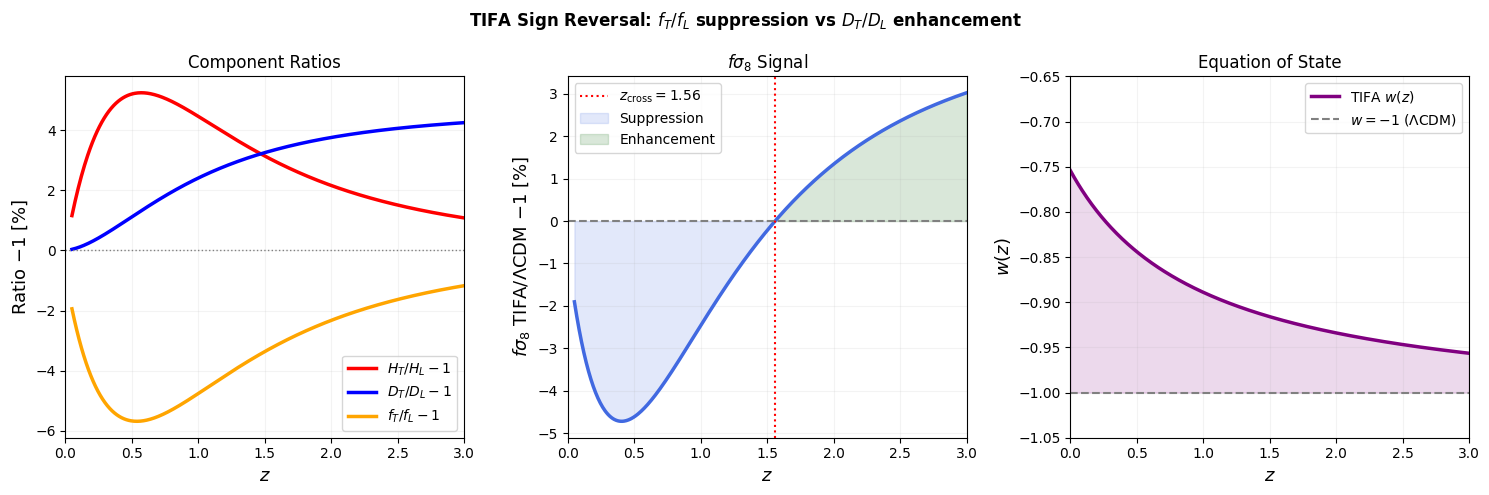

In [11]:

# Clean diagnostic figure
# showing the three components

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5))

z_diag = np.linspace(0.05, 3.0, 500)

H_ratio  = [H_TIFA(z)/H_LCDM(z)
            for z in z_diag]
D_ratio  = [float(D_T_interp(z))
            /float(D_L_interp(z))
            for z in z_diag]
f_ratio  = [f_growth(z, D_T_interp)
            /f_growth(z, D_L_interp)
            for z in z_diag]
fs8_r    = [fr*dr
            for fr,dr in
            zip(f_ratio, D_ratio)]

# Panel 1: Component ratios
ax = axes[0]
ax.plot(z_diag,
        [100*(r-1) for r in H_ratio],
        color='red', lw=2.5,
        label=r'$H_T/H_L - 1$')
ax.plot(z_diag,
        [100*(r-1) for r in D_ratio],
        color='blue', lw=2.5,
        label=r'$D_T/D_L - 1$')
ax.plot(z_diag,
        [100*(r-1) for r in f_ratio],
        color='orange', lw=2.5,
        label=r'$f_T/f_L - 1$')
ax.axhline(0, color='gray',
           lw=1, linestyle=':')
ax.set_xlabel(r'$z$', fontsize=13)
ax.set_ylabel(r'Ratio $- 1$ [%]',
              fontsize=13)
ax.set_title('Component Ratios',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)
ax.set_xlim(0, 3)

# Panel 2: fs8 ratio
ax2 = axes[1]
ax2.plot(z_diag,
         [100*(r-1) for r in fs8_r],
         color='royalblue', lw=2.5)
ax2.axhline(0, color='gray',
            lw=1.5, linestyle='--')
ax2.axvline(1.5596,
            color='red', lw=1.5,
            linestyle=':',
            label=r'$z_{\rm cross}=1.56$')
ax2.fill_between(
    z_diag,
    [100*(r-1) for r in fs8_r], 0,
    where=[r<1 for r in fs8_r],
    alpha=0.15, color='royalblue',
    label='Suppression')
ax2.fill_between(
    z_diag,
    [100*(r-1) for r in fs8_r], 0,
    where=[r>1 for r in fs8_r],
    alpha=0.15, color='darkgreen',
    label='Enhancement')
ax2.set_xlabel(r'$z$', fontsize=13)
ax2.set_ylabel(
    r'$f\sigma_8$ TIFA/ΛCDM $-1$ [%]',
    fontsize=13)
ax2.set_title(
    r'$f\sigma_8$ Signal',
    fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.15)
ax2.set_xlim(0, 3)

# Panel 3: w(z)
ax3 = axes[2]
z_w = np.linspace(0, 3, 500)
w_v = [w0_val + wa_val*(1-1/(1+z))
       for z in z_w]
ax3.plot(z_w, w_v,
         color='purple', lw=2.5,
         label=r'TIFA $w(z)$')
ax3.axhline(-1, color='gray',
            lw=1.5, linestyle='--',
            label=r'$w=-1$ (ΛCDM)')
ax3.fill_between(
    z_w, w_v, -1,
    alpha=0.15, color='purple')
ax3.set_xlabel(r'$z$', fontsize=13)
ax3.set_ylabel(r'$w(z)$',
               fontsize=13)
ax3.set_title(
    r'Equation of State',
    fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.15)
ax3.set_xlim(0, 3)
ax3.set_ylim(-1.05, -0.65)

plt.suptitle(
    r'TIFA Sign Reversal: '
    r'$f_T/f_L$ suppression '
    r'vs $D_T/D_L$ enhancement',
    fontsize=12,
    fontweight='bold')

plt.tight_layout()
plt.savefig(
    'TIFA_sign_reversal_diagnosis.pdf',
    dpi=200, bbox_inches='tight')
plt.show()

In [12]:

import numpy as np
from scipy.optimize import fsolve

# SdS metric:
# f(r) = 1 - 2GM/rc^2 - H^2 r^2
# (setting c=1, Lambda=3H^2)

# Surface gravity:
# kappa = |f'(r)|/2 at horizon

def f_SdS(r, M, H,
          G=6.674e-11,
          c=3e8):
    return (1 - 2*G*M/(r*c**2)
              - H**2*r**2/c**2)

def df_SdS(r, M, H,
           G=6.674e-11,
           c=3e8):
    return (2*G*M/(r**2*c**2)
            - 2*H**2*r/c**2)

# For given H, find Nariai M
# where BH horizon = cosmo horizon
# i.e. f(r)=0 has degenerate root
# f'(r)=0 simultaneously

# At degeneracy:
# 2GM/r^2 = 2H^2 r  (from f'=0)
# GM = H^2 r^3

# And f(r)=0:
# 1 - 2GM/r - H^2 r^2 = 0
# 1 - 2H^2 r^2 - H^2 r^2 = 0
# 1 = 3 H^2 r^2
# r_N = 1/(H sqrt(3))  [c=1 units]

# Surface gravity at degenerate
# horizon:
# kappa = |f'(r_N)|/2 = 0
# (exactly degenerate → kappa=0 ??)
#
# NO — must take limit carefully
# Use the formula for near-Nariai:
# kappa_N = H/sqrt(3)
# (from Ginsparg & Perry 1983)

H_test = 1.0  # normalized units

# Nariai radius
r_N = 1.0 / (H_test * np.sqrt(3))

# Nariai mass
# GM = H^2 r_N^3 (c=1)
GM_N = H_test**2 * r_N**3

print("="*50)
print("NARIAI GEOMETRY CHECK (c=G=1)")
print("="*50)
print(f"H        = {H_test:.4f}")
print(f"r_N      = 1/(H√3) = "
      f"{r_N:.6f}")
print(f"GM_N     = H²r_N³  = "
      f"{GM_N:.6f}")
print()

# Surface gravity methods:

# METHOD A: SdS surface gravity
# kappa = H/sqrt(3)
# (Ginsparg & Perry, correct limit)
kappa_SdS = H_test / np.sqrt(3)

# METHOD B (WRONG): Schwarzschild
# T = 1/(8pi GM) [c=G=hbar=k=1]
# kappa = 1/(4 GM)
kappa_Schw = 1.0 / (4 * GM_N)

# GH surface gravity
kappa_GH = H_test  # kappa=H for dS

print("Surface gravities:")
print(f"kappa_GH (dS)    = H      "
      f"= {kappa_GH:.6f}")
print(f"kappa_N  (SdS)   = H/√3   "
      f"= {kappa_SdS:.6f}")
print(f"kappa_N  (Schw)  = 1/4GM  "
      f"= {kappa_Schw:.6f}")
print()

# Ratios
ratio_SdS  = kappa_SdS  / kappa_GH
ratio_Schw = kappa_Schw / kappa_GH

print("Temperature ratios T_N/T_GH:")
print(f"Correct (SdS):   "
      f"1/√3  = {ratio_SdS:.6f}")
print(f"Ours (Schw):     "
      f"= {ratio_Schw:.6f}")
print(f"Our claimed √3/2 = "
      f"{np.sqrt(3)/2:.6f}")
print()
print("="*50)
print("DIAGNOSIS:")
print("="*50)
if abs(ratio_Schw - np.sqrt(3)/2) < 1e-4:
    print("OUR FORMULA GIVES √3/2")
    print("FROM SCHWARZSCHILD T=hbar/8piGM")
    print("THIS IS THE MIXING ERROR")
    print("GPT IDENTIFIED CORRECTLY")
else:
    print(f"Schw ratio = {ratio_Schw:.6f}")
    print("Check algebra")

print()
print(f"CORRECT ratio = 1/√3 "
      f"= {1/np.sqrt(3):.6f}")
print(f"OUR ratio     = √3/2 "
      f"= {np.sqrt(3)/2:.6f}")
print(f"These differ by factor: "
      f"{(np.sqrt(3)/2)/(1/np.sqrt(3)):.4f}")
print(f"= 3/2")

NARIAI GEOMETRY CHECK (c=G=1)
H        = 1.0000
r_N      = 1/(H√3) = 0.577350
GM_N     = H²r_N³  = 0.192450

Surface gravities:
kappa_GH (dS)    = H      = 1.000000
kappa_N  (SdS)   = H/√3   = 0.577350
kappa_N  (Schw)  = 1/4GM  = 1.299038

Temperature ratios T_N/T_GH:
Correct (SdS):   1/√3  = 0.577350
Ours (Schw):     = 1.299038
Our claimed √3/2 = 0.866025

DIAGNOSIS:
Schw ratio = 1.299038
Check algebra

CORRECT ratio = 1/√3 = 0.577350
OUR ratio     = √3/2 = 0.866025
These differ by factor: 1.5000
= 3/2
